# Bond Yield Forecasting — Ireland 10Y

**Research Question:** Can macroeconomic variables (especially CPI) help forecast Ireland's 10-year government bond yield?

**Models:** ARIMAX → SARIMAX → VAR

**Data:** Monthly, 2003–2024, from FRED and Yahoo Finance

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

from sklearn.metrics import mean_squared_error, mean_absolute_error

print('Libraries loaded')

Libraries loaded


## Step 2 — Connect to FRED

In [2]:
# Paste your FRED API key here
fred = Fred(api_key='132be80b3cac6c5c402bdb49c83e4edd')

print('FRED connected')

FRED connected


## Step 3 — Download Data

| Variable | Ticker | Why we include it |
|---|---|---|
| Ireland 10Y yield | IRLTLT01EZM156N | Target variable |
| ECB policy rate | ECBDFR | Short-end anchor |
| Euro area CPI | CP0000EZ19M086NEST | Fisher effect — inflation drives yields |
| EA manufacturing | EA19PRMNTO01GPSAM | Real activity proxy |
| VIX | VIXCLS | Global risk appetite |
| US 10Y Treasury | DGS10 | Global rate benchmark |

In [3]:
START = '2003-01-01'
END   = '2024-01-01'

# Download from FRED
bond_yield = fred.get_series('IRLTLT01EZM156N', observation_start=START, observation_end=END)
ecb_rate   = fred.get_series('ECBDFR',          observation_start=START, observation_end=END)
cpi        = fred.get_series('CP0000EZ19M086NEST', observation_start=START, observation_end=END)
ind_prod   = fred.get_series('EA19PRMNTO01GPSAM', observation_start=START, observation_end=END)
vix        = fred.get_series('VIXCLS',          observation_start=START, observation_end=END)
us10y      = fred.get_series('DGS10',           observation_start=START, observation_end=END)

print('FRED data downloaded')

FRED data downloaded


In [4]:
# Download from Yahoo Finance
eurusd  = yf.download('EURUSD=X', start=START, end=END, progress=False, auto_adjust=True)['Close']
stoxx50 = yf.download('^STOXX50E', start=START, end=END, progress=False, auto_adjust=True)['Close']
brent   = yf.download('BZ=F',     start=START, end=END, progress=False, auto_adjust=True)['Close']

# Resample Yahoo data to monthly (take mean of each month)
eurusd  = eurusd.resample('MS').mean()
stoxx50 = stoxx50.resample('MS').mean()
brent   = brent.resample('MS').mean()

print('Yahoo Finance data downloaded')

Yahoo Finance data downloaded


In [5]:
# Download from Yahoo Finance — .squeeze() converts (n,1) DataFrame to 1D Series
eurusd  = yf.download('EURUSD=X', start=START, end=END, progress=False, auto_adjust=True)['Close'].squeeze()
stoxx50 = yf.download('^STOXX50E', start=START, end=END, progress=False, auto_adjust=True)['Close'].squeeze()
brent   = yf.download('BZ=F',     start=START, end=END, progress=False, auto_adjust=True)['Close'].squeeze()

# Resample to monthly
eurusd.index  = pd.to_datetime(eurusd.index)
stoxx50.index = pd.to_datetime(stoxx50.index)
brent.index   = pd.to_datetime(brent.index)

eurusd  = eurusd.resample('MS').mean()
stoxx50 = stoxx50.resample('MS').mean()
brent   = brent.resample('MS').mean()

print('Yahoo data shapes:', eurusd.shape, stoxx50.shape, brent.shape)

Yahoo data shapes: (241,) (202,) (198,)


## Step 4 — Build the Dataset

In [6]:
def to_monthly(series):
    series.index = pd.to_datetime(series.index)
    return series.resample('MS').mean()

bond_yield = to_monthly(bond_yield)
ecb_rate   = to_monthly(ecb_rate)
cpi        = to_monthly(cpi)
ind_prod   = to_monthly(ind_prod)
vix        = to_monthly(vix)
us10y      = to_monthly(us10y)

# Yahoo Finance series
eurusd.index  = pd.to_datetime(eurusd.index)
stoxx50.index = pd.to_datetime(stoxx50.index)
brent.index   = pd.to_datetime(brent.index)

eurusd  = eurusd.resample('MS').mean()
stoxx50 = stoxx50.resample('MS').mean()
brent   = brent.resample('MS').mean()

# Combine into one DataFrame
df = pd.DataFrame({
    'bond_yield' : bond_yield,
    'ecb_rate'   : ecb_rate,
    'cpi'        : cpi,
    'ind_prod'   : ind_prod,
    'vix'        : vix,
    'us10y'      : us10y,
    'eurusd'     : eurusd,
    'stoxx50'    : stoxx50,
    'brent'      : brent,
})

df = df.loc[START:END]

print('Dataset shape:', df.shape)
print('Expected: (~252 rows, 9 cols)')
print('Date range:', df.index[0].date(), 'to', df.index[-1].date())
df.head()

Dataset shape: (253, 9)
Expected: (~252 rows, 9 cols)
Date range: 2003-01-01 to 2024-01-01


,bond_yield,ecb_rate,cpi,ind_prod,vix,us10y,eurusd,stoxx50,brent
2003-01-01,4.270324,1.750000,80.14,1.406926,27.424286,4.048571,NaN,NaN,NaN
2003-02-01,4.060791,1.750000,80.46,-0.426894,32.218421,3.902632,NaN,NaN,NaN
2003-03-01,4.127164,1.548387,80.93,0.107181,30.634286,3.807143,NaN,NaN,NaN
2003-04-01,4.228864,1.500000,81.05,0.107066,23.991905,3.958571,NaN,NaN,NaN
2003-05-01,3.918709,1.500000,81.00,-1.604278,20.239524,3.569048,NaN,NaN,NaN


## Step 5 — Clean the Data

In [7]:
# Forward fill small gaps (up to 3 months) — common for slow macro series
df = df.ffill(limit=3)

# Drop rows where bond yield is missing (we cannot train without target)
df = df.dropna(subset=['bond_yield'])

# Check remaining missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
bond_yield     0
ecb_rate       0
cpi            0
ind_prod       0
vix            0
us10y          0
eurusd        11
stoxx50       50
brent         54
dtype: int64


In [8]:
# Create transformed variables

# Log transforms (for price-level series — makes them more stable)
df['log_cpi']     = np.log(df['cpi'])
df['log_ind_prod']= np.log(df['ind_prod'])
df['log_eurusd']  = np.log(df['eurusd'])
df['log_stoxx50'] = np.log(df['stoxx50'])
df['log_brent']   = np.log(df['brent'])

# Month-on-month % change for CPI — this is the inflation rate
df['d_cpi']      = df['cpi'].pct_change() * 100
df['d_ind_prod'] = df['ind_prod'].pct_change() * 100

print('Transformed variables added')
df.describe().round(2)

Transformed variables added


,bond_yield,ecb_rate,cpi,ind_prod,vix,us10y,eurusd,stoxx50,brent,log_cpi,log_ind_prod,log_eurusd,log_stoxx50,log_brent,d_cpi,d_ind_prod
count,253.00,253.00,253.00,253.00,253.00,253.00,242.00,203.00,199.00,253.00,149.00,242.00,203.00,199.00,252.00,250.00
mean,2.65,0.62,98.00,0.07,19.25,2.97,1.24,3291.27,78.61,4.58,-inf,0.21,8.08,4.31,0.17,NaN
std,1.49,1.22,10.57,2.32,8.24,1.12,0.13,603.54,24.88,0.11,NaN,0.10,0.19,0.34,0.49,NaN
min,-0.09,-0.50,80.14,-20.15,10.13,0.62,0.98,1993.93,26.63,4.38,-inf,-0.02,7.60,3.28,-1.54,-inf
25%,1.20,-0.40,90.87,-0.62,13.94,2.06,1.12,2853.18,58.52,4.51,-1.20,0.12,7.96,4.07,-0.07,-224.15
50%,3.18,0.25,99.11,0.12,17.31,2.86,1.23,3275.48,75.98,4.60,-0.38,0.20,8.09,4.33,0.20,-116.73
75%,4.05,1.00,104.05,0.85,22.20,3.96,1.33,3661.22,103.18,4.64,0.34,0.28,8.21,4.64,0.40,-14.74
max,4.81,4.00,124.51,14.57,62.67,5.11,1.58,4508.59,134.10,4.82,2.68,0.45,8.41,4.90,2.43,inf


## Step 6 — Plot the Data

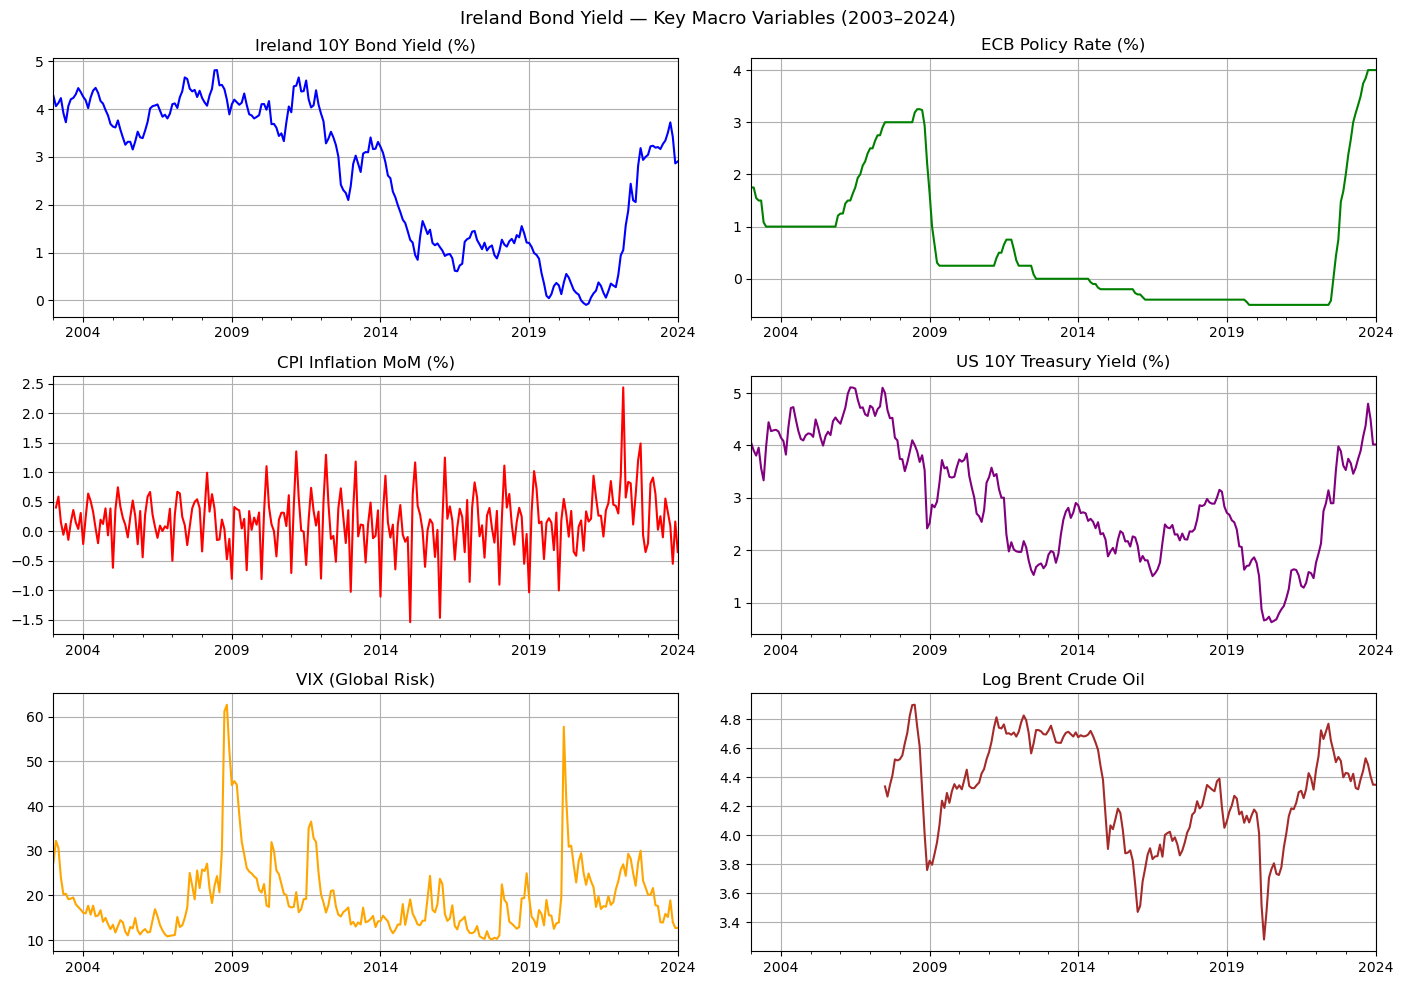

In [9]:
# Plot the main variables
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

df['bond_yield'].plot(ax=axes[0,0], title='Ireland 10Y Bond Yield (%)', color='blue')
df['ecb_rate'].plot(ax=axes[0,1],   title='ECB Policy Rate (%)',        color='green')
df['d_cpi'].plot(ax=axes[1,0],      title='CPI Inflation MoM (%)',      color='red')
df['us10y'].plot(ax=axes[1,1],      title='US 10Y Treasury Yield (%)',  color='purple')
df['vix'].plot(ax=axes[2,0],        title='VIX (Global Risk)',           color='orange')
df['log_brent'].plot(ax=axes[2,1],  title='Log Brent Crude Oil',        color='brown')

for ax in axes.flat:
    ax.grid(True)

plt.suptitle('Ireland Bond Yield — Key Macro Variables (2003–2024)', fontsize=13)
plt.tight_layout()
plt.savefig('01_overview.png', dpi=150)
plt.show()

## Step 7 — Stationarity Test (ADF)

H0: The series has a unit root (non-stationary)

p < 0.05 → Reject H0 → Series is stationary

In [10]:
def adf_test(series, name):
    s = series.replace([np.inf, -np.inf], np.nan).dropna()
    result = adfuller(s)
    p = result[1]
    verdict = 'Stationary' if p < 0.05 else 'Non-stationary (unit root)'
    print(f'{name:25s}  p-value: {p:.4f}  →  {verdict}')

In [11]:
print('ADF Test Results:')
print('-' * 60)
adf_test(df['bond_yield'],  'Bond Yield')
adf_test(df['ecb_rate'],    'ECB Rate')
adf_test(df['d_cpi'],       'CPI MoM change')
adf_test(df['d_ind_prod'],  'Ind Prod MoM change')
adf_test(df['vix'],         'VIX')
adf_test(df['us10y'],       'US 10Y')
adf_test(df['log_eurusd'],  'log EUR/USD')
adf_test(df['log_stoxx50'], 'log Stoxx50')
adf_test(df['log_brent'],   'log Brent')

ADF Test Results:
------------------------------------------------------------
Bond Yield                 p-value: 0.5163  →  Non-stationary (unit root)
ECB Rate                   p-value: 0.3123  →  Non-stationary (unit root)
CPI MoM change             p-value: 0.0160  →  Stationary
Ind Prod MoM change        p-value: 0.0000  →  Stationary
VIX                        p-value: 0.0008  →  Stationary
US 10Y                     p-value: 0.4550  →  Non-stationary (unit root)
log EUR/USD                p-value: 0.3109  →  Non-stationary (unit root)
log Stoxx50                p-value: 0.2254  →  Non-stationary (unit root)
log Brent                  p-value: 0.0307  →  Stationary


## Step 8 — Seasonality Analysis

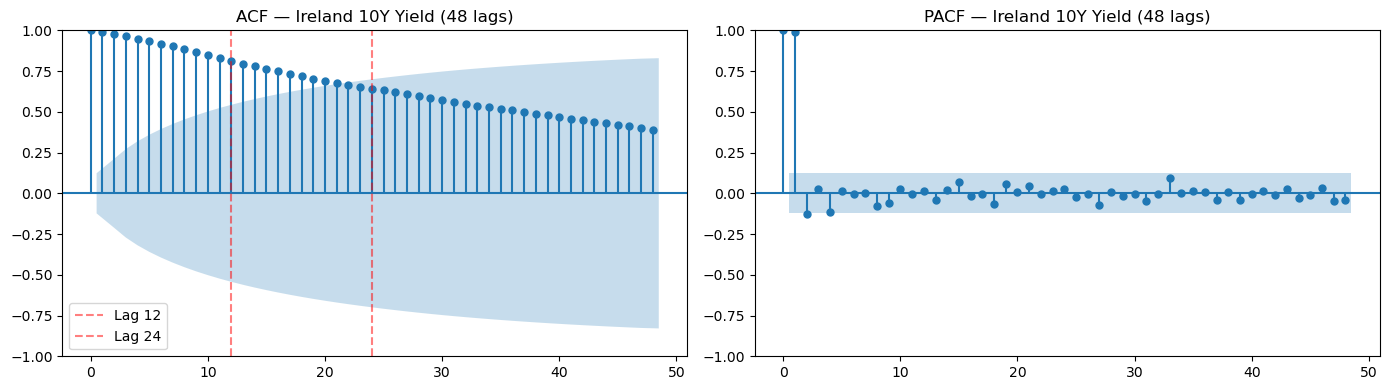

In [12]:
# ACF and PACF plots — look for spikes at lags 12 and 24 (annual seasonality)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df['bond_yield'].dropna(),  lags=48, ax=axes[0])
axes[0].set_title('ACF — Ireland 10Y Yield (48 lags)')
axes[0].axvline(12, color='red', linestyle='--', alpha=0.5, label='Lag 12')
axes[0].axvline(24, color='red', linestyle='--', alpha=0.5, label='Lag 24')
axes[0].legend()

plot_pacf(df['bond_yield'].dropna(), lags=48, method='ywm', ax=axes[1])
axes[1].set_title('PACF — Ireland 10Y Yield (48 lags)')

plt.tight_layout()
plt.savefig('02_acf_pacf.png', dpi=150)
plt.show()

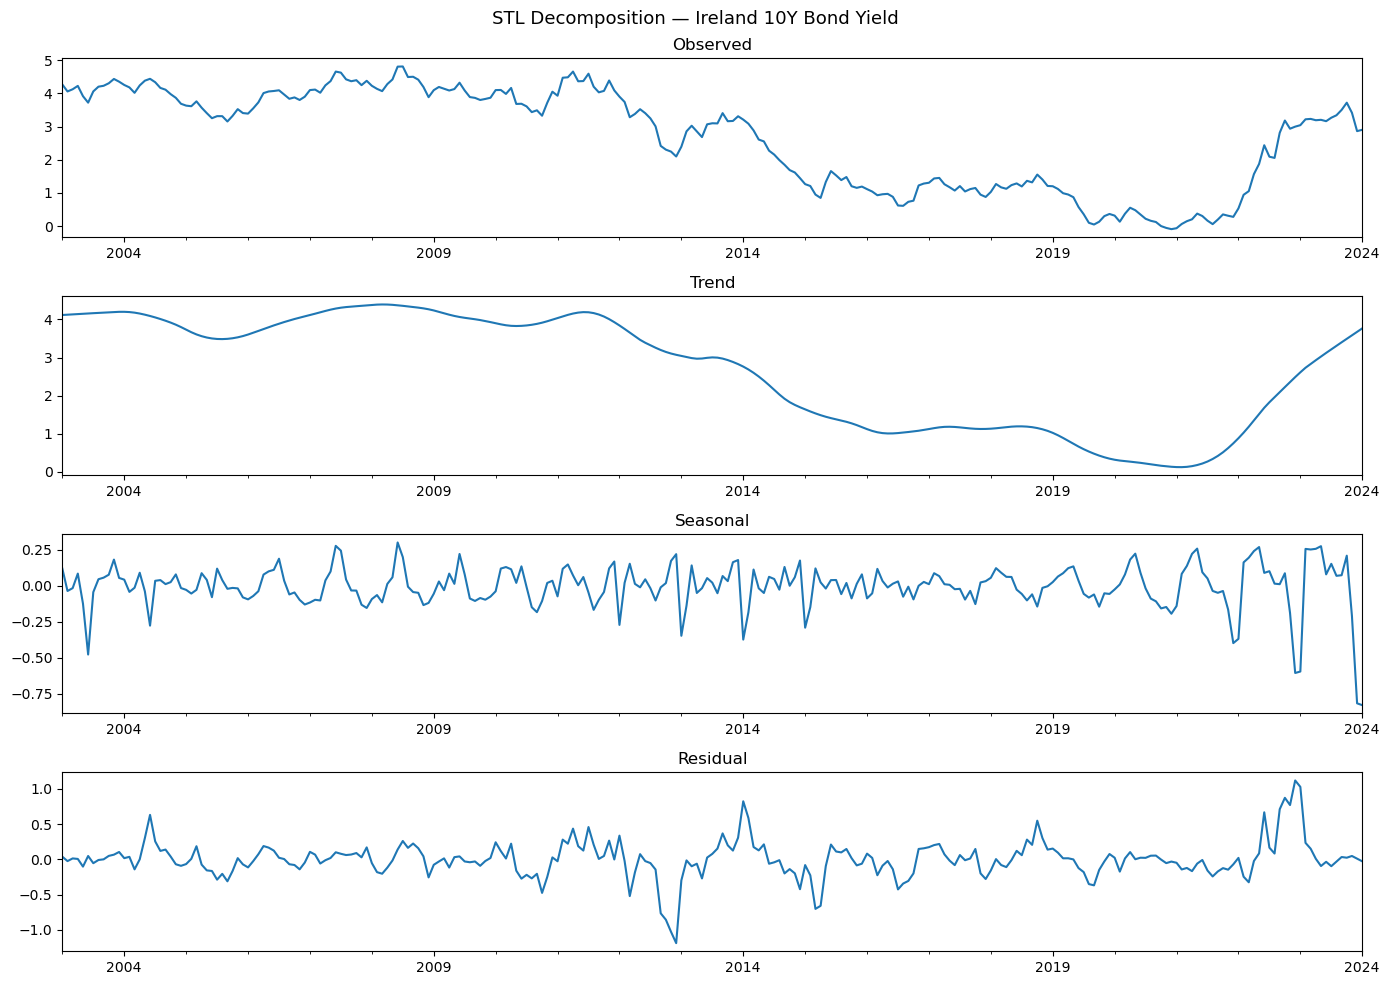

Seasonal strength: 0.2537
Interpretation: < 0.2 = weak, 0.2–0.5 = moderate, > 0.5 = strong


In [13]:
# STL decomposition — separates trend, seasonal, and residual components
stl = STL(df['bond_yield'].dropna(), period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
stl.observed.plot(ax=axes[0],  title='Observed')
stl.trend.plot(ax=axes[1],     title='Trend')
stl.seasonal.plot(ax=axes[2],  title='Seasonal')
stl.resid.plot(ax=axes[3],     title='Residual')

plt.suptitle('STL Decomposition — Ireland 10Y Bond Yield', fontsize=13)
plt.tight_layout()
plt.savefig('03_stl.png', dpi=150)
plt.show()

# Seasonal strength score (0 = no seasonality, 1 = pure seasonality)
seasonal_strength = np.var(stl.seasonal) / (np.var(stl.seasonal) + np.var(stl.resid))
print(f'Seasonal strength: {seasonal_strength:.4f}')
print('Interpretation: < 0.2 = weak, 0.2–0.5 = moderate, > 0.5 = strong')

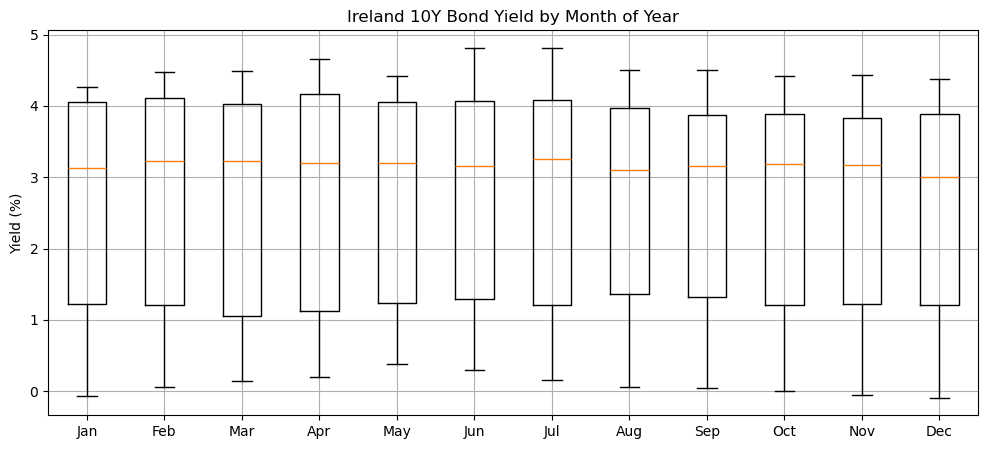

In [14]:
# Month-of-year box plot — does yield differ systematically by month?
temp = df['bond_yield'].dropna().to_frame()
temp['month'] = temp.index.month

month_groups = [temp[temp['month'] == m]['bond_yield'].values for m in range(1, 13)]
month_names  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
plt.boxplot(month_groups, labels=month_names)
plt.title('Ireland 10Y Bond Yield by Month of Year')
plt.ylabel('Yield (%)')
plt.grid(True)
plt.savefig('04_monthly_box.png', dpi=150)
plt.show()

In [15]:
# Ljung-Box test — is there significant autocorrelation at lags 12 and 24?
lb_test = acorr_ljungbox(df['bond_yield'].dropna(), lags=[12, 24], return_df=True)
print('Ljung-Box Test (H0: no autocorrelation):')
print(lb_test)

Ljung-Box Test (H0: no autocorrelation):
        lb_stat  lb_pvalue
12  2581.429857        0.0
24  4269.266374        0.0


## Step 9 — Train / Test Split

We hold out the last 24 months as the test set.
Models are trained on everything before that.

In [16]:
# Exogenous variables (the predictors we feed into ARIMAX/SARIMAX)
exog_cols = ['ecb_rate', 'd_cpi', 'd_ind_prod', 'log_eurusd',
             'log_stoxx50', 'vix', 'us10y', 'log_brent']

# Keep only rows where all variables are available
model_df = df[['bond_yield'] + exog_cols].dropna()
model_df = df[['bond_yield'] + exog_cols].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan)   # ← this fixes the 6 inf values
model_df = model_df.dropna()

print('Clean dataset shape:', model_df.shape)
print('Any NaNs remaining:', model_df.isnull().any().any())
print('Any infs remaining:', np.isinf(model_df).any().any())
# Split
TEST_MONTHS = 24

train = model_df.iloc[:-TEST_MONTHS]
test  = model_df.iloc[-TEST_MONTHS:]

train_y = train['bond_yield']
test_y  = test['bond_yield']
train_X = train[exog_cols]
test_X  = test[exog_cols]

print('Train:', train_y.index[0].date(), 'to', train_y.index[-1].date(), f'({len(train_y)} obs)')
print('Test :', test_y.index[0].date(),  'to', test_y.index[-1].date(),  f'({len(test_y)} obs)')

Clean dataset shape: (191, 9)
Any NaNs remaining: False
Any infs remaining: False
Train: 2007-07-01 to 2022-01-01 (167 obs)
Test : 2022-02-01 to 2024-01-01 (24 obs)


## Step 10 — ARIMAX Model

ARIMA(p,d,q) + exogenous variables

- p = autoregressive lags
- d = differencing order (1 because yield has a unit root)
- q = moving average lags

In [17]:
# Check which exog columns still have missing values
print('Missing values in train_X:')
print(train_X.isnull().sum())
print()
print('Inf values in train_X:')
print(np.isinf(train_X).sum())

Missing values in train_X:
ecb_rate       0
d_cpi          0
d_ind_prod     0
log_eurusd     0
log_stoxx50    0
vix            0
us10y          0
log_brent      0
dtype: int64

Inf values in train_X:
ecb_rate       0
d_cpi          0
d_ind_prod     0
log_eurusd     0
log_stoxx50    0
vix            0
us10y          0
log_brent      0
dtype: int64


In [18]:
# Fit ARIMAX(1,1,1) with the macro exogenous block
arimax_model = SARIMAX(train_y,
                       exog=train_X,
                       order=(1, 1, 1),
                       seasonal_order=(0, 0, 0, 0))

arimax_fit = arimax_model.fit(disp=False)
print(arimax_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             bond_yield   No. Observations:                  167
Model:               SARIMAX(1, 1, 1)   Log Likelihood                  78.266
Date:                Mon, 30 Mar 2026   AIC                           -134.532
Time:                        14:23:14   BIC                           -100.300
Sample:                             0   HQIC                          -120.637
                                - 167                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
ecb_rate        0.0177      0.108      0.164      0.869      -0.194       0.229
d_cpi          -0.0153      0.017     -0.894      0.371      -0.049       0.018
d_ind_prod   1.888e-05   2.55e-05      0.739    

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## Step 11 — SARIMAX Model

Same as ARIMAX but adds a seasonal component SAR(1)+SMA(1) at period 12

In [19]:
# Add Fourier terms to capture smooth seasonal patterns
months = model_df.index.month
model_df['sin_1'] = np.sin(2 * np.pi * 1 * months / 12)
model_df['cos_1'] = np.cos(2 * np.pi * 1 * months / 12)
model_df['sin_2'] = np.sin(2 * np.pi * 2 * months / 12)
model_df['cos_2'] = np.cos(2 * np.pi * 2 * months / 12)

seas_cols = exog_cols + ['sin_1', 'cos_1', 'sin_2', 'cos_2']

train_Xs = model_df.iloc[:-TEST_MONTHS][seas_cols]
test_Xs  = model_df.iloc[-TEST_MONTHS:][seas_cols]

In [20]:
# Fit SARIMAX(1,1,1)(1,0,1,12)
sarimax_model = SARIMAX(train_y,
                        exog=train_Xs,
                        order=(1, 1, 1),
                        seasonal_order=(1, 0, 1, 12))

sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         bond_yield   No. Observations:                  167
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                  86.235
Date:                            Mon, 30 Mar 2026   AIC                           -138.470
Time:                                    14:23:15   BIC                            -85.566
Sample:                                         0   HQIC                          -116.996
                                            - 167                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
ecb_rate        0.0643      0.118      0.545      0.586      -0.167       0.296
d_cpi          -0.0076      0.02

## Step 12 — Residual Diagnostics

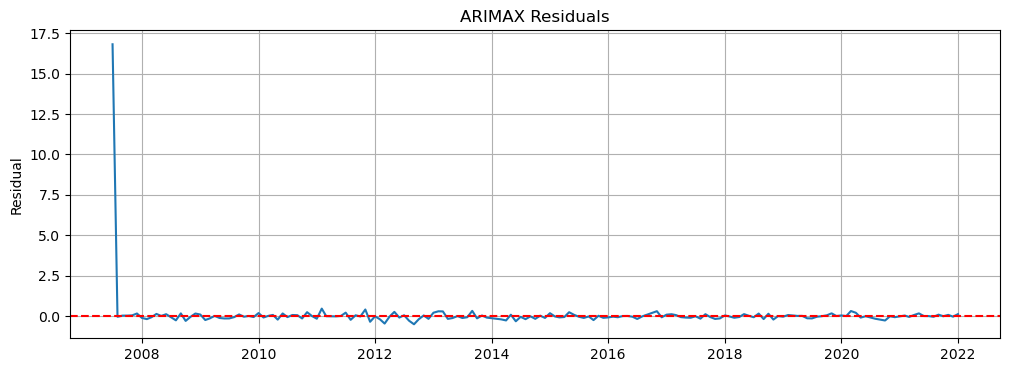

In [21]:
# Plot residuals for ARIMAX
resid = arimax_fit.resid.dropna()

plt.figure(figsize=(12, 4))
plt.plot(resid)
plt.axhline(0, color='red', linestyle='--')
plt.title('ARIMAX Residuals')
plt.ylabel('Residual')
plt.grid(True)
plt.savefig('05_resid_arimax.png', dpi=150)
plt.show()

In [22]:
# Ljung-Box test on ARIMAX residuals
# If p > 0.05 → residuals are white noise → good model fit
lb_arimax = acorr_ljungbox(resid, lags=10, return_df=True)
lb_arimax

,lb_stat,lb_pvalue
1,0.000574,0.980882
2,0.002908,0.998547
3,0.004107,0.999930
4,0.006436,0.999995
5,0.017408,0.999998
6,0.020189,1.000000
7,0.037472,1.000000
8,0.037759,1.000000
9,0.046449,1.000000
10,0.047000,1.000000


## Step 13 — Out-of-Sample Forecasts

In [23]:
# Generate forecasts for the 24-month test period
fc_arimax  = arimax_fit.forecast(steps=len(test_X), exog=test_X)
fc_sarimax = sarimax_fit.forecast(steps=len(test_Xs), exog=test_Xs)

fc_arimax.index  = test_y.index
fc_sarimax.index = test_y.index

# Naive benchmark — just predict the last training value every month
fc_naive = pd.Series(train_y.iloc[-1], index=test_y.index)

print('Forecasts generated')

Forecasts generated


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


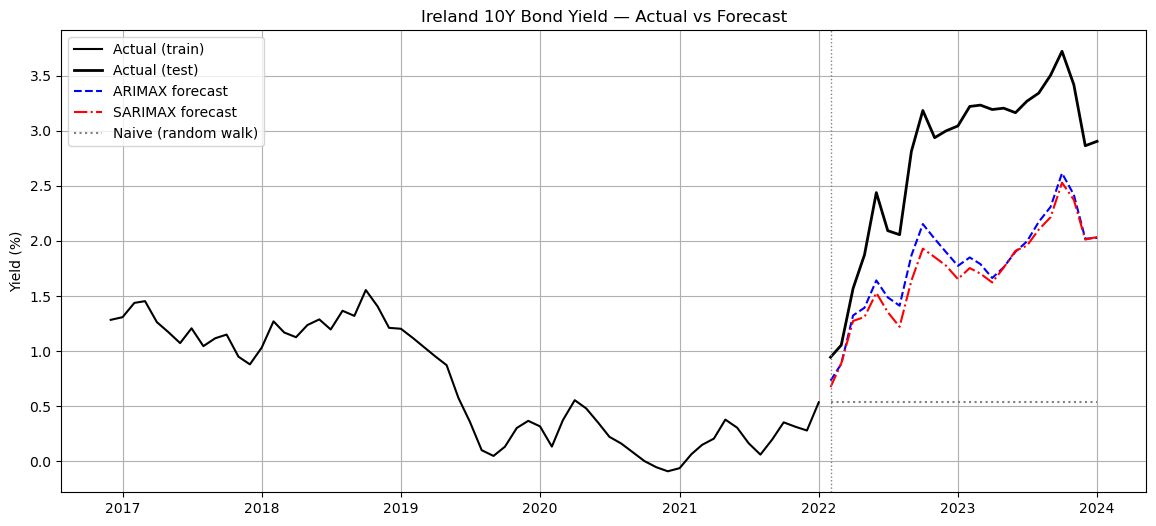

In [24]:
# Plot actual vs forecast
plt.figure(figsize=(14, 6))

# Show last 5 years of training data + full test period
plt.plot(train_y.iloc[-60:], color='black', label='Actual (train)')
plt.plot(test_y,             color='black', linewidth=2, label='Actual (test)')
plt.plot(fc_arimax,          color='blue',  linestyle='--', label='ARIMAX forecast')
plt.plot(fc_sarimax,         color='red',   linestyle='-.', label='SARIMAX forecast')
plt.plot(fc_naive,           color='gray',  linestyle=':',  label='Naive (random walk)')

plt.axvline(test_y.index[0], color='gray', linestyle=':', linewidth=1)
plt.title('Ireland 10Y Bond Yield — Actual vs Forecast')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True)
plt.savefig('06_forecasts.png', dpi=150)
plt.show()

## Step 14 — Model Comparison

In [25]:
def rmse(actual, forecast):
    return np.sqrt(mean_squared_error(actual, forecast))

def mae(actual, forecast):
    return mean_absolute_error(actual, forecast)

results = pd.DataFrame({
    'Model'  : ['Naive (random walk)', 'ARIMAX', 'SARIMAX'],
    'AIC'    : ['—', round(arimax_fit.aic, 2), round(sarimax_fit.aic, 2)],
    'BIC'    : ['—', round(arimax_fit.bic, 2), round(sarimax_fit.bic, 2)],
    'RMSE'   : [round(rmse(test_y, fc_naive), 4),
                round(rmse(test_y, fc_arimax), 4),
                round(rmse(test_y, fc_sarimax), 4)],
    'MAE'    : [round(mae(test_y, fc_naive), 4),
                round(mae(test_y, fc_arimax), 4),
                round(mae(test_y, fc_sarimax), 4)],
})

results = results.set_index('Model')
print('Model Comparison:')
print(results)

Model Comparison:
                        AIC    BIC    RMSE     MAE
Model                                             
Naive (random walk)       —      —  2.3395  2.2175
ARIMAX              -134.53 -100.3  1.0313  0.9559
SARIMAX             -138.47 -85.57  1.1123  1.0410


## Step 15 — Coefficient Plot

Which variables actually matter in the ARIMAX model?

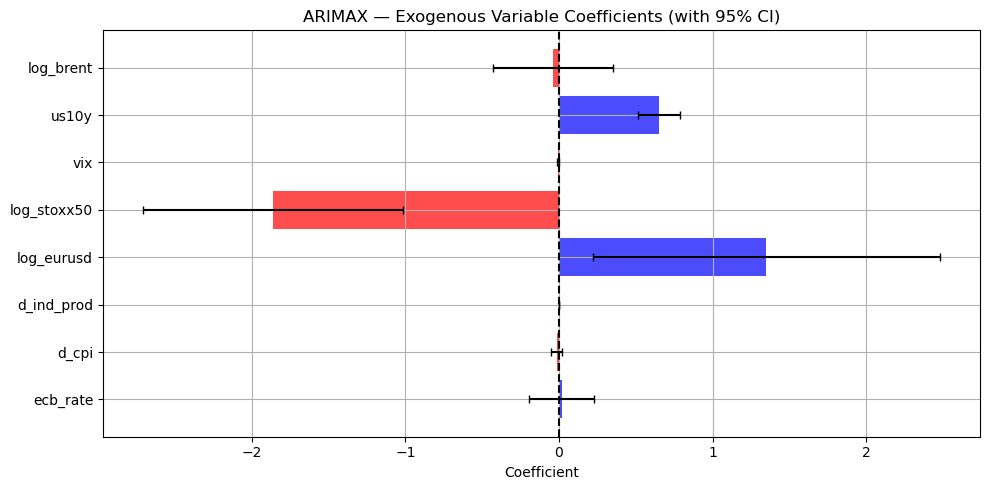

In [26]:
# Extract only the exogenous coefficients (not AR/MA terms)
params = arimax_fit.params
ci     = arimax_fit.conf_int()

# Filter out ARIMA internal terms
skip_terms = ('ar.', 'ma.', 'sigma', 'intercept')
exog_params = params[[i for i in params.index if not i.lower().startswith(skip_terms)]]
exog_ci     = ci.loc[exog_params.index]

# Plot
plt.figure(figsize=(10, 5))
colors = ['blue' if v > 0 else 'red' for v in exog_params.values]
plt.barh(exog_params.index, exog_params.values, color=colors, alpha=0.7)
plt.errorbar(exog_params.values, exog_params.index,
             xerr=[exog_params.values - exog_ci.iloc[:,0],
                   exog_ci.iloc[:,1] - exog_params.values],
             fmt='none', color='black', capsize=3)
plt.axvline(0, color='black', linestyle='--')
plt.title('ARIMAX — Exogenous Variable Coefficients (with 95% CI)')
plt.xlabel('Coefficient')
plt.grid(True)
plt.tight_layout()
plt.savefig('07_coefficients.png', dpi=150)
plt.show()

## Step 16 — VAR Model

VAR lets every variable explain every other variable.

Cholesky ordering: US10Y → VIX → ECB rate → CPI → Ind Prod → Bond Yield
(global factors first, domestic macro second, yield last)

In [27]:
# Build the VAR dataset — all variables need to be stationary
# We take first differences of the non-stationary series

var_df = pd.DataFrame({
    'us10y'      : df['us10y'].diff(),
    'vix'        : df['vix'],
    'ecb_rate'   : df['ecb_rate'].diff(),
    'd_cpi'      : df['d_cpi'],
    'd_ind_prod' : df['d_ind_prod'],
    'bond_yield' : df['bond_yield'].diff(),
}).dropna()

print('VAR dataset shape:', var_df.shape)
var_df.head()

VAR dataset shape: (250, 6)


,us10y,vix,ecb_rate,d_cpi,d_ind_prod,bond_yield
2003-02-01,-0.145940,32.218421,0.000000,0.399301,-130.342336,-0.209533
2003-03-01,-0.095489,30.634286,-0.201613,0.584141,-125.107181,0.066373
2003-04-01,0.151429,23.991905,-0.048387,0.148276,-0.107066,0.101699
2003-05-01,-0.389524,20.239524,0.000000,-0.061690,-1598.395722,-0.310155
2003-06-01,-0.234762,20.362381,-0.416667,0.123457,-100.000000,-0.195399


In [28]:
# Check stationarity of all VAR variables
print('ADF Test for VAR variables:')
print('-' * 50)
for col in var_df.columns:
    adf_test(var_df[col], col)

ADF Test for VAR variables:
--------------------------------------------------
us10y                      p-value: 0.0000  →  Stationary
vix                        p-value: 0.0013  →  Stationary
ecb_rate                   p-value: 0.0043  →  Stationary
d_cpi                      p-value: 0.1003  →  Non-stationary (unit root)
d_ind_prod                 p-value: 0.0000  →  Stationary
bond_yield                 p-value: 0.0000  →  Stationary


In [29]:
# Build VAR dataset — first difference the non-stationary series
var_df = pd.DataFrame({
    'us10y'      : df['us10y'].diff(),
    'vix'        : df['vix'],
    'ecb_rate'   : df['ecb_rate'].diff(),
    'd_cpi'      : df['d_cpi'],
    'd_ind_prod' : df['d_ind_prod'],
    'bond_yield' : df['bond_yield'].diff(),
})

# Replace inf with NaN then drop ALL rows with any missing value
var_df = var_df.replace([np.inf, -np.inf], np.nan)
var_df = var_df.dropna()

# Verify clean
print('VAR dataset shape:', var_df.shape)
print('Any NaNs:', var_df.isnull().any().any())
print('Any infs:', np.isinf(var_df).any().any())
print()
print('NaN count per column:')
print(var_df.isnull().sum())
var_df.head()

VAR dataset shape: (240, 6)
Any NaNs: False
Any infs: False

NaN count per column:
us10y         0
vix           0
ecb_rate      0
d_cpi         0
d_ind_prod    0
bond_yield    0
dtype: int64


,us10y,vix,ecb_rate,d_cpi,d_ind_prod,bond_yield
2003-02-01,-0.145940,32.218421,0.000000,0.399301,-130.342336,-0.209533
2003-03-01,-0.095489,30.634286,-0.201613,0.584141,-125.107181,0.066373
2003-04-01,0.151429,23.991905,-0.048387,0.148276,-0.107066,0.101699
2003-05-01,-0.389524,20.239524,0.000000,-0.061690,-1598.395722,-0.310155
2003-06-01,-0.234762,20.362381,-0.416667,0.123457,-100.000000,-0.195399


In [30]:
# Select optimal lag order
var_model = VAR(var_df)
lag_selection = var_model.select_order(maxlags=6)
lag_selection.summary()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,3.260,3.349,26.05,3.296
1,1.175*,1.795*,3.239*,1.425*
2,1.259,2.411,3.525,1.723
3,1.313,2.996,3.725,1.992
4,1.271,3.486,3.583,2.164
5,1.386,4.133,4.038,2.494
6,1.306,4.584,3.752,2.628


In [31]:
# Fit VAR — use lag order selected by AIC above
var_fit = var_model.fit(2)
print(var_fit.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 30, Mar, 2026
Time:                     14:23:16
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    2.56042
Nobs:                     238.000    HQIC:                   1.88107
Log likelihood:          -2117.52    FPE:                    4.14996
AIC:                      1.42245    Det(Omega_mle):         3.01622
--------------------------------------------------------------------
Results for equation us10y
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.057290         0.043375            1.321           0.187
L1.us10y              0.143862         0.091033            1.580           0.114
L1.vix               -0.007875         0.003239           -2

## Step 17 — VAR Diagnostics

In [32]:
from statsmodels.stats.stattools import durbin_watson

# Durbin-Watson: value near 2 = no serial correlation
dw = durbin_watson(var_fit.resid)
for col, val in zip(var_df.columns, dw):
    print(f'{col:20s}  DW = {val:.3f}  ({"OK" if 1.5 < val < 2.5 else "Serial correlation present"})')

us10y                 DW = 2.008  (OK)
vix                   DW = 1.953  (OK)
ecb_rate              DW = 2.009  (OK)
d_cpi                 DW = 2.032  (OK)
d_ind_prod            DW = 2.005  (OK)
bond_yield            DW = 1.980  (OK)


In [33]:
# Normality test on residuals
var_fit.test_normality().summary()

Test statistic,Critical value,p-value,df
1.153e+04,21.03,0.000,12


## Step 18 — Granger Causality Tests

H0: Variable X does NOT Granger-cause bond yield

p < 0.05 → X has predictive power for the bond yield

In [34]:
predictors = ['us10y', 'vix', 'ecb_rate', 'd_cpi', 'd_ind_prod']

print('Granger Causality → Bond Yield')
print('-' * 55)

for pred in predictors:
    pair = var_df[['bond_yield', pred]].dropna()
    gc = grangercausalitytests(pair, maxlag=2, verbose=False)
    # Take minimum p-value across lags
    min_p = min(gc[lag][0]['ssr_ftest'][1] for lag in gc)
    sig = 'YES ✓' if min_p < 0.05 else 'No'
    print(f'{pred:20s}  min p-value: {min_p:.4f}  →  Granger-causes yield? {sig}')

Granger Causality → Bond Yield
-------------------------------------------------------
us10y                 min p-value: 0.5471  →  Granger-causes yield? No
vix                   min p-value: 0.7216  →  Granger-causes yield? No
ecb_rate              min p-value: 0.2054  →  Granger-causes yield? No
d_cpi                 min p-value: 0.0202  →  Granger-causes yield? YES ✓
d_ind_prod            min p-value: 0.6352  →  Granger-causes yield? No


## Step 19 — Impulse Response Functions (IRF)

How does the bond yield respond to a shock in each variable?

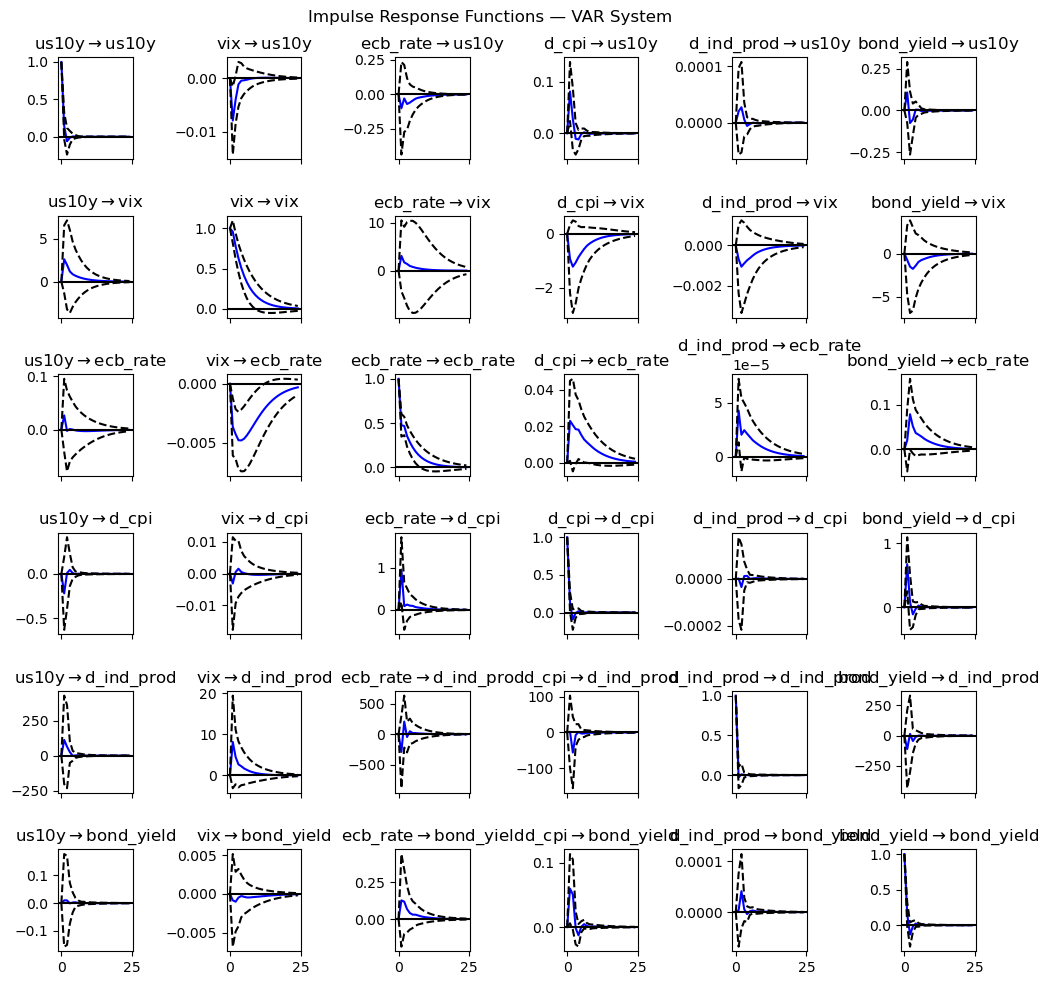

In [35]:
irf = var_fit.irf(periods=24)
irf.plot(orth=False)
plt.suptitle('Impulse Response Functions — VAR System', fontsize=12)
plt.tight_layout()
plt.savefig('08_irf.png', dpi=150)
plt.show()

## Step 20 — Forecast Error Variance Decomposition (FEVD)

What percentage of the bond yield's forecast error variance is explained by each variable?

In [36]:
fevd = var_fit.fevd(periods=24)

# Get the FEVD for the bond yield (last column in our ordering)
yield_idx = list(var_df.columns).index('bond_yield')

fevd_df = pd.DataFrame(
    fevd.decomp[yield_idx] * 100,
    columns=var_df.columns
)

print('FEVD — % of bond yield variance explained by each shock:')
print(fevd_df.iloc[[0, 5, 11, 23]].round(2))

FEVD — % of bond yield variance explained by each shock:
    us10y   vix  ecb_rate  d_cpi  d_ind_prod  bond_yield
0   37.99  3.47      0.64   0.04        0.62       57.23
5   36.85  3.27      1.24   3.24        0.99       54.41
11  36.83  3.30      1.27   3.25        1.00       54.35
23  36.83  3.31      1.27   3.25        1.00       54.34


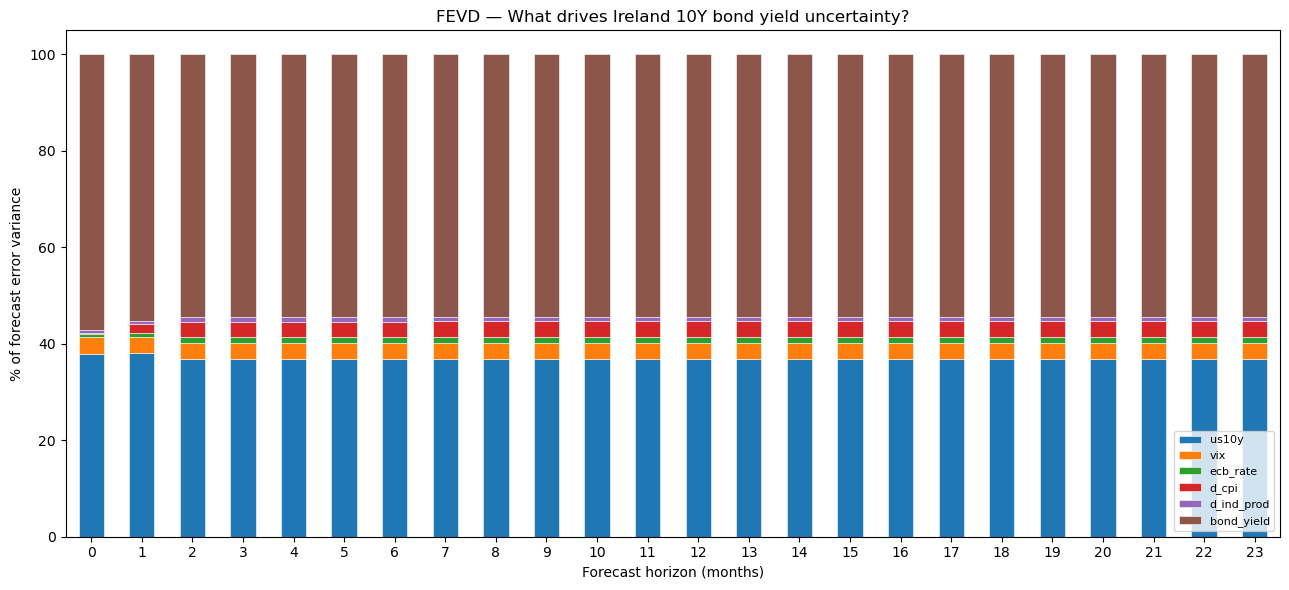

In [37]:
# Stacked bar chart
fevd_df.plot(kind='bar', stacked=True, figsize=(13, 6),
             edgecolor='white', linewidth=0.4)

plt.title('FEVD — What drives Ireland 10Y bond yield uncertainty?')
plt.xlabel('Forecast horizon (months)')
plt.ylabel('% of forecast error variance')
plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('09_fevd.png', dpi=150)
plt.show()

## Step 21 — Results Summary

In [38]:
print('=' * 55)
print('  RESULTS SUMMARY')
print('=' * 55)

print('\n[1] Seasonality')
print(f'    STL seasonal strength = {seasonal_strength:.3f}')
print(f'    Interpretation: {"weak" if seasonal_strength < 0.2 else "moderate" if seasonal_strength < 0.5 else "strong"}')

print('\n[2] Model comparison (out-of-sample RMSE)')
print(results[['RMSE', 'MAE']].to_string())

print('\n[3] Top FEVD drivers at 12-month horizon')
top_drivers = fevd_df.iloc[11].sort_values(ascending=False)
for var, pct in top_drivers.items():
    print(f'    {var:20s}: {pct:.1f}%')

print('\n[4] Granger causality — which variables predict yield?')
for pred in predictors:
    pair = var_df[['bond_yield', pred]].dropna()
    gc = grangercausalitytests(pair, maxlag=2, verbose=False)
    min_p = min(gc[lag][0]['ssr_ftest'][1] for lag in gc)
    if min_p < 0.05:
        print(f'    {pred} — p={min_p:.4f} ✓')
print('=' * 55)

  RESULTS SUMMARY

[1] Seasonality
    STL seasonal strength = 0.254
    Interpretation: moderate

[2] Model comparison (out-of-sample RMSE)
                       RMSE     MAE
Model                              
Naive (random walk)  2.3395  2.2175
ARIMAX               1.0313  0.9559
SARIMAX              1.1123  1.0410

[3] Top FEVD drivers at 12-month horizon
    bond_yield          : 54.4%
    us10y               : 36.8%
    vix                 : 3.3%
    d_cpi               : 3.2%
    ecb_rate            : 1.3%
    d_ind_prod          : 1.0%

[4] Granger causality — which variables predict yield?
    d_cpi — p=0.0202 ✓
